In [1]:
import pyrfume
import pandas as pd
from pprint import pprint
from IPython.display import Image

/Users/pn254/miniforge3/envs/odor_analysis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
burton_manifest = pyrfume.load_manifest("burton_2022")
pprint(burton_manifest, width=150)

{'code': {'main.py': 'Processing workflow'},
 'parsed': {'raw/XXXX_ROIPos.csv': 'X and Y coordinates for the centroids of each ROI (glom) in each experiment XXXX; exported from '
                                   "odormappingdata_simple_05_2022.mat file because Matlab 'table' class is not Python readable"},
 'processed': {'behavior.csv': 'DeltaF response values of every ROI (glomerulus) for every odorant/mouse tested',
               'molecules.csv': 'Information about odorant molecules used',
               'stimuli.csv': 'Maps stimuli to CID and odor concentrations used for each subject',
               'subjects.csv': 'Maps subject ID to mouse ID, olfactory bulb hemisphere, and ROI#'},
 'raw': {'raw/odormappingdata_simple_05_2022.mat': '.mat file containig deltaF response matrices and odorant concentrations. See main.py for full '
                                                   'details'},
 'source': {'authors': ' SD Burton, A Brown, TP Eiting, IA Youngstrom, TC Rust, M Schmuker

In [3]:
# Image(filename="schematic_2.png", width=800)

In [4]:

burton_stimuli = pyrfume.load_data("burton_2022/stimuli.csv")
burton_stimuli.head()

,CID,Conc. (mols/L)
Stimulus,,
1001_3.12e-13,1001.0,3.120000e-13
101010_9.38e-11,101010.0,9.384700e-11
10248_5.34e-12,10248.0,5.341713e-12
10315_5.57e-11,10315.0,5.570500e-11
10315_5.57e-12,10315.0,5.570500e-12


In [5]:
burton_molecules = pyrfume.load_data("burton_2022/molecules.csv")
burton_molecules.head()

,MolecularWeight,IsomericSMILES,IUPACName,name
CID,,,,
240,106.12,C1=CC=C(C=C1)C=O,benzaldehyde,benzaldehyde
261,72.11,CCCC=O,butanal,butyraldehyde
264,88.11,CCCC(=O)O,butanoic acid,butyric acid
273,102.18,C(CCN)CCN,"pentane-1,5-diamine",cadaverine
323,146.14,C1=CC=C2C(=C1)C=CC(=O)O2,chromen-2-one,coumarin


In [6]:
'''
Beginning my analysis
'''

my_names = ["1-hexanol", "1-octen-3-ol", "2-heptanone", "acetophenone", "ethyl butyrate", "methyl salicylate", "octyl acetate", "trans-2-hexen-1-al", "pentyl acetate"]

In [7]:
from pyrfume import get_cids

cids = get_cids(my_names)

1-hexanol:   0%|                                         | 0/9 [00:00<?, ?it/s][17:39:18] ERROR: 

1-octen-3-ol:  11%|███▎                          | 1/9 [00:00<00:03,  2.31it/s][17:39:19] ERROR: 

2-heptanone:  22%|██████▉                        | 2/9 [00:00<00:02,  2.60it/s][17:39:19] ERROR: 

acetophenone:  33%|██████████                    | 3/9 [00:01<00:02,  2.69it/s][17:39:19] ERROR: 

ethyl butyrate:  44%|████████████▍               | 4/9 [00:01<00:01,  2.62it/s][17:39:20] ERROR: 

methyl salicylate:  56%|█████████████▉           | 5/9 [00:01<00:01,  2.57it/s][17:39:20] ERROR: 

octyl acetate:  67%|███████████████████▎         | 6/9 [00:02<00:01,  2.69it/s][17:39:21] ERROR: 

trans-2-hexen-1-al:  78%|██████████████████▋     | 7/9 [00:02<00:00,  2.39it/s][17:39:21] ERROR: 

pentyl acetate:  89%|████████████████████████▉   | 8/9 [00:03<00:00,  2.63it/s][17:39:21] ERROR: 

pentyl acetate: 100%|████████████████████████████| 9/9 [00:03<00:00,  2.58it/s]


In [8]:
cids

cids = pd.Series(cids)

cids

1-hexanol                8103
1-octen-3-ol            18827
2-heptanone              8051
acetophenone             7410
ethyl butyrate           7762
methyl salicylate        4133
octyl acetate            8164
trans-2-hexen-1-al    5281168
pentyl acetate          12348
dtype: int64

In [9]:
from pyrfume import from_cids

info = from_cids(cids.values)

molecules = pd.DataFrame(info).set_index("CID")
molecules

100%|████████████████████████████████████████████| 1/1 [00:01<00:00,  1.21s/it]


,MolecularWeight,SMILES,IUPACName,name
CID,,,,
8103,102.17,CCCCCCO,hexan-1-ol,1-hexanol
18827,128.21,CCCCCC(C=C)O,oct-1-en-3-ol,1-octen-3-ol
8051,114.19,CCCCCC(=O)C,heptan-2-one,2-heptanone
7410,120.15,CC(=O)C1=CC=CC=C1,1-phenylethanone,acetophenone
7762,116.16,CCCC(=O)OCC,ethyl butanoate,ethyl butyrate
4133,152.15,COC(=O)C1=CC=CC=C1O,methyl 2-hydroxybenzoate,methyl salicylate
8164,172.26,CCCCCCCCOC(=O)C,octyl acetate,octyl acetate
5281168,98.14,CCC/C=C/C=O,(E)-hex-2-enal,trans-2-hexenal
12348,130.18,CCCCCOC(=O)C,pentyl acetate,amyl acetate


In [10]:
pyrfume.save_data(molecules, "my_data/molecules.csv")

In [11]:
import pyrfume

molecules = pyrfume.load_data(
    "my_data/molecules.csv"
)  # Load the data we created in the last chapter
cids = molecules.index.tolist()

In [12]:
smiles = molecules["SMILES"].tolist()
smiles

['CCCCCCO',
 'CCCCCC(C=C)O',
 'CCCCCC(=O)C',
 'CC(=O)C1=CC=CC=C1',
 'CCCC(=O)OCC',
 'COC(=O)C1=CC=CC=C1O',
 'CCCCCCCCOC(=O)C',
 'CCC/C=C/C=O',
 'CCCCCOC(=O)C']

In [13]:
from pyrfume.features import smiles_to_mordred

mordred_features = smiles_to_mordred(smiles)

100%|███████████████████████████████████████████| 9/9 [00:00<00:00, 183.63it/s]


Computing Mordred features...



100%|████████████████████████████████████████████| 9/9 [00:02<00:00,  4.42it/s]

There are 9 molecules and 1826 features


In [14]:
mordred_features

,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
CCCCCCO,4.242641,4.53095,0,0,8.054679,1.847759,3.695518,8.054679,1.150668,2.739193,...,6.900731,30.25721,102.104465,4.862117,56,4,22.0,20.0,3.25,2.0
CCCCCC(C=C)O,5.766244,6.027282,0,0,10.472136,2.0,4.0,10.472136,1.163571,3.007971,...,7.739359,34.994205,128.120115,5.124805,110,7,32.0,31.0,4.361111,2.416667
CCCCCC(=O)C,5.168527,5.361851,0,0,8.762573,1.949856,3.899712,8.762573,1.095322,2.887985,...,7.475906,33.09036,114.104465,5.186567,79,5,28.0,26.0,4.111111,2.083333
CC(=O)C1=CC=CC=C1,6.542301,6.236096,0,0,11.189957,2.193993,4.387987,11.189957,1.243329,3.089765,...,8.590258,37.289972,120.057515,7.062207,88,9,40.0,43.0,3.472222,2.111111
CCCC(=O)OCC,5.059137,5.456585,0,0,8.828427,2.0,4.0,8.828427,1.103553,2.888532,...,7.65681,33.420942,116.08373,5.804186,75,6,28.0,27.0,4.111111,2.166667
COC(=O)C1=CC=CC=C1O,7.916074,7.703487,0,0,13.631431,2.281843,4.563687,13.631431,1.239221,3.287086,...,8.99628,40.725137,152.047344,8.002492,152,14,50.0,56.0,4.583333,2.638889
CCCCCCCCOC(=O)C,7.996954,7.498781,0,0,13.910306,1.979643,3.959286,13.910306,1.159192,3.298627,...,7.927685,39.313723,172.14633,5.379573,277,9,44.0,42.0,5.111111,3.083333
CCC/C=C/C=O,4.242641,4.53095,0,0,8.054679,1.847759,3.695518,8.054679,1.150668,2.739193,...,6.900731,30.25721,98.073165,5.76901,56,4,22.0,20.0,3.25,2.0
CCCCCOC(=O)C,5.875634,5.943785,0,0,10.251662,1.961571,3.923141,10.251662,1.139074,3.007497,...,7.609367,34.745525,130.09938,5.656495,114,6,32.0,30.0,4.361111,2.333333


In [15]:
from pyrfume.features import smiles_to_morgan

morgan_features = smiles_to_morgan(smiles)

Computing Morgan Fingerprints:   0%|                     | 0/9 [00:00<?, ?it/s][17:39:27] DEPRECATION WARNING: please use MorganGenerator
[17:39:27] DEPRECATION WARNING: please use MorganGenerator
[17:39:27] DEPRECATION WARNING: please use MorganGenerator
[17:39:27] DEPRECATION WARNING: please use MorganGenerator
[17:39:27] DEPRECATION WARNING: please use MorganGenerator
[17:39:27] DEPRECATION WARNING: please use MorganGenerator
[17:39:27] DEPRECATION WARNING: please use MorganGenerator
[17:39:27] DEPRECATION WARNING: please use MorganGenerator
[17:39:27] DEPRECATION WARNING: please use MorganGenerator
Computing Morgan Fingerprints: 100%|███████████| 9/9 [00:00<00:00, 9807.41it/s]


In [16]:
morgan_features


,245196591,300276709,313049873,864662311,980906191,1343183050,1367963776,1418257574,1675301946,1732062363,...,3034004479,3399982621,3419024974,3712613290,813747866,1943769122,1975906251,3599604464,3876798682,4060121710
CCCCCCO,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CCCCCC(C=C)O,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CCCCCC(=O)C,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CC(=O)C1=CC=CC=C1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CCCC(=O)OCC,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
COC(=O)C1=CC=CC=C1O,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CCCCCCCCOC(=O)C,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CCC/C=C/C=O,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
CCCCCOC(=O)C,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0


In [17]:
from pyrfume.features import smiles_to_morgan_sim

morgan_sim_features = smiles_to_morgan_sim(smiles, smiles)

100%|███████████████████████████████████████████| 9/9 [00:00<00:00, 216.15it/s]
[17:39:28] DEPRECATION WARNING: please use MorganGenerator
[17:39:28] DEPRECATION WARNING: please use MorganGenerator
[17:39:28] DEPRECATION WARNING: please use MorganGenerator
[17:39:28] DEPRECATION WARNING: please use MorganGenerator
[17:39:28] DEPRECATION WARNING: please use MorganGenerator
[17:39:28] DEPRECATION WARNING: please use MorganGenerator
[17:39:28] DEPRECATION WARNING: please use MorganGenerator
[17:39:28] DEPRECATION WARNING: please use MorganGenerator
[17:39:28] DEPRECATION WARNING: please use MorganGenerator
[17:39:28] DEPRECATION WARNING: please use MorganGenerator
[17:39:28] DEPRECATION WARNING: please use MorganGenerator
[17:39:28] DEPRECATION WARNING: please use MorganGenerator
[17:39:28] DEPRECATION WARNING: please use MorganGenerator
[17:39:28] DEPRECATION WARNING: please use MorganGenerator
[17:39:28] DEPRECATION WARNING: please use MorganGenerator
[17:39:28] DEPRECATION WARNING: ple

In [18]:
morgan_sim_features


,CCCCCCO,CCCCCC(C=C)O,CCCCCC(=O)C,CC(=O)C1=CC=CC=C1,CCCC(=O)OCC,COC(=O)C1=CC=CC=C1O,CCCCCCCCOC(=O)C,CCC/C=C/C=O,CCCCCOC(=O)C
CCCCCCO,1.000000,0.629921,0.655172,0.220183,0.500000,0.235294,0.575163,0.450980,0.622951
CCCCCC(C=C)O,0.629921,1.000000,0.589147,0.196721,0.448000,0.212121,0.481928,0.434783,0.562963
CCCCCC(=O)C,0.655172,0.589147,1.000000,0.288288,0.631579,0.247934,0.593548,0.461538,0.741935
CC(=O)C1=CC=CC=C1,0.220183,0.196721,0.288288,1.000000,0.280374,0.526316,0.216216,0.268041,0.273504
CCCC(=O)OCC,0.500000,0.448000,0.631579,0.280374,1.000000,0.273504,0.490066,0.480000,0.616667
COC(=O)C1=CC=CC=C1O,0.235294,0.212121,0.247934,0.526316,0.273504,1.000000,0.202532,0.242991,0.251969
CCCCCCCCOC(=O)C,0.575163,0.481928,0.593548,0.216216,0.490066,0.202532,1.000000,0.340426,0.732919
CCC/C=C/C=O,0.450980,0.434783,0.461538,0.268041,0.480000,0.242991,0.340426,1.000000,0.436364
CCCCCOC(=O)C,0.622951,0.562963,0.741935,0.273504,0.616667,0.251969,0.732919,0.436364,1.000000


In [19]:
from pyrfume.odorants import all_cids


reference_smiles = all_cids()




#smiles_to_morgan_sim(smiles, reference_smiles)

In [20]:
from pyrfume.odorants import all_odorants

reference_odors = all_odorants()

In [21]:
reference_odors

,MolecularWeight,IsomericSMILES,IUPACName,name
CID,,,,
-955348933095,240.387,CCCCC=COC(=O)CCCCCCCC,NaN,Hexenyl nonanoate
-923209957509,196.290,CC(=O)OCC1C=CC(C(C)C)CC1,NaN,Tetrahydrocuminyl acetate
-874408321546,244.331,CCCCCCCCC(OC(C)=O)C(=O)OC,NaN,Methyl acetoxydecanoate
-873963935677,198.306,CCCCC=COC(=O)C(C)CCC,NaN,Hexenyl methylvalerate
-862841422647,148.271,CCCC(S)COCC,NaN,Ethoxymethylbutanethiol
...,...,...,...,...
160829480,158.190,CCC#CC(C)C.C(=O)(O)O,carbonic acid;2-methylhex-3-yne,carbonic acid;2-methylhex-3-yne
161504856,212.330,CCCCCCCC=COC(=O)CCC,non-1-enyl butanoate,non-1-enyl butanoate
162353069,246.500,C(CSCCC(S)S)C(S)S,"3-[3,3-bis(sulfanyl)propylsulfanyl]propane-1,1...","3-[3,3-bis(sulfanyl)propylsulfanyl]propane-1,1..."


In [22]:

reference_smiles = pd.Series(reference_smiles)

reference_smiles

0       -955348933095
1       -923209957509
2       -874408321546
3       -873963935677
4       -862841422647
             ...     
10294       160829480
10295       161504856
10296       162353069
10297       163709488
10298       163735825
Length: 10299, dtype: int64

In [23]:
'''
They fucked their all_smiles() import so have to manually get the smiles from the cid numbers using code
takes about 2-3min

info = from_cids(reference_smiles.values)

reference_molecules = pd.DataFrame(info).set_index("CID")
reference_molecules
'''

'\nThey fucked their all_smiles() import so have to manually get the smiles from the cid numbers using code\ntakes about 2-3min\n\ninfo = from_cids(reference_smiles.values)\n\nreference_molecules = pd.DataFrame(info).set_index("CID")\nreference_molecules\n'

In [24]:
#smiles_to_morgan_sim(smiles, list(reference_odors["IsomericSMILES"][1:5000]))

In [25]:
#morgan_sim = pyrfume.load_data("morgan/features_sim.csv", cids=cids)


In [26]:
#mordred = pyrfume.load_data("mordred/features.csv", cids=cids)

In [27]:
pprint(reference_odors["IsomericSMILES"].str.strip())

CID
-955348933095        CCCCC=COC(=O)CCCCCCCC
-923209957509     CC(=O)OCC1C=CC(C(C)C)CC1
-874408321546    CCCCCCCCC(OC(C)=O)C(=O)OC
-873963935677         CCCCC=COC(=O)C(C)CCC
-862841422647                  CCCC(S)COCC
                           ...            
 160829480            CCC#CC(C)C.C(=O)(O)O
 161504856             CCCCCCCC=COC(=O)CCC
 162353069               C(CSCCC(S)S)C(S)S
 163709488                 CCC1CCC(O1)(C)O
 163735825           C1CCCCCOC(=O)CCOCCCC1
Name: IsomericSMILES, Length: 10299, dtype: object


In [28]:
reference_odors["IsomericSMILES"][4]

'CC(CN)O'

In [29]:
smiles

['CCCCCCO',
 'CCCCCC(C=C)O',
 'CCCCCC(=O)C',
 'CC(=O)C1=CC=CC=C1',
 'CCCC(=O)OCC',
 'COC(=O)C1=CC=CC=C1O',
 'CCCCCCCCOC(=O)C',
 'CCC/C=C/C=O',
 'CCCCCOC(=O)C']

In [30]:
import pyrfume

try:
    import seaborn as sns

    sns.set(font_scale=1.5)
    sns.set_style("whitegrid")
except:
    pass  # Seaborn is not installed

molecules = pyrfume.load_data("my_data/molecules.csv")  # Load the data from the last chapter

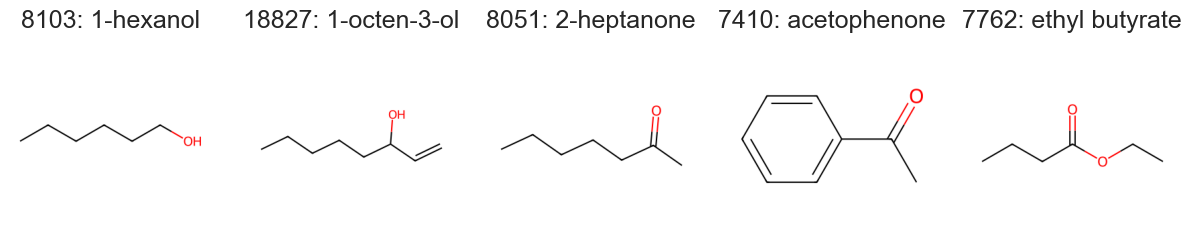

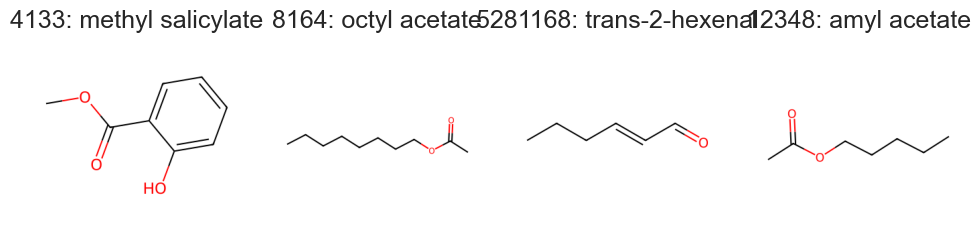

In [31]:
from pyrfume.odorants import display_molecules

display_molecules(molecules)

In [32]:
import pyrfume

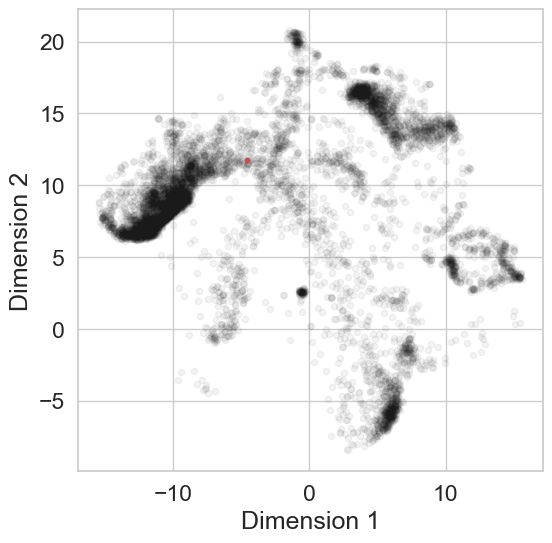

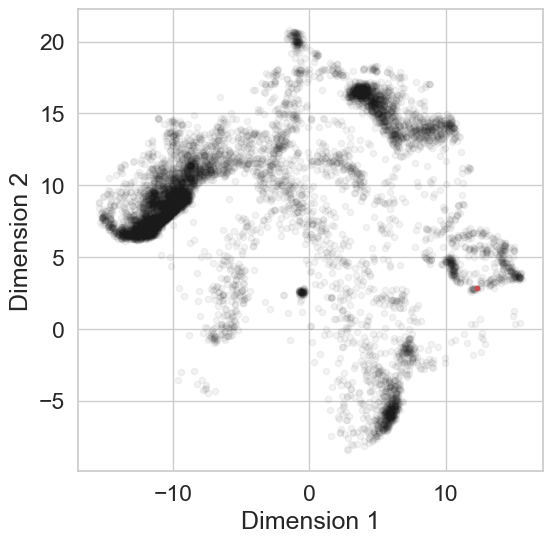

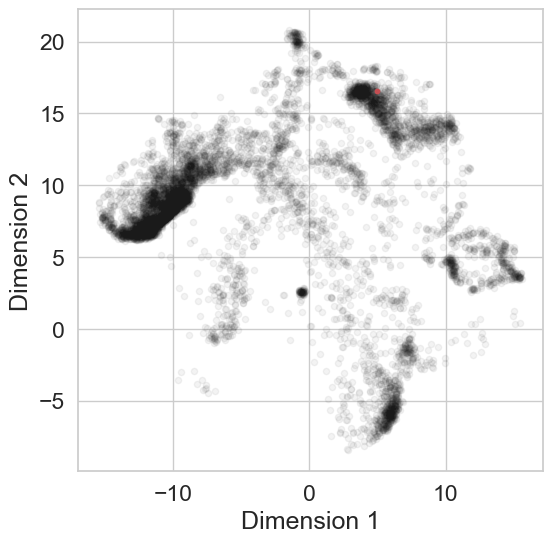

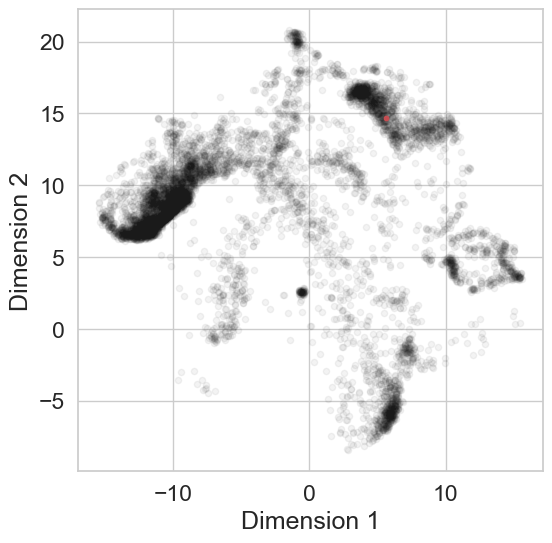

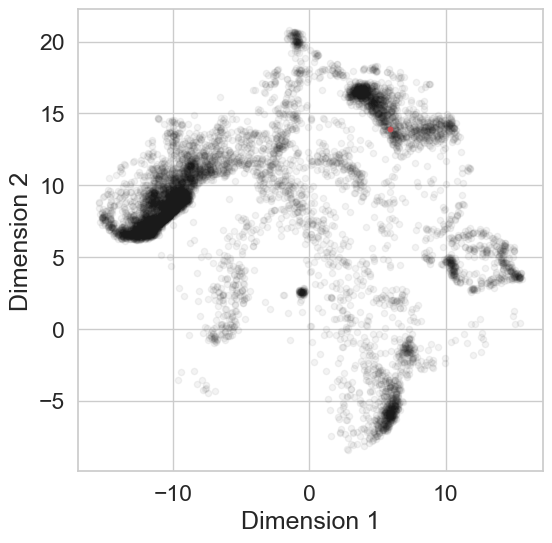

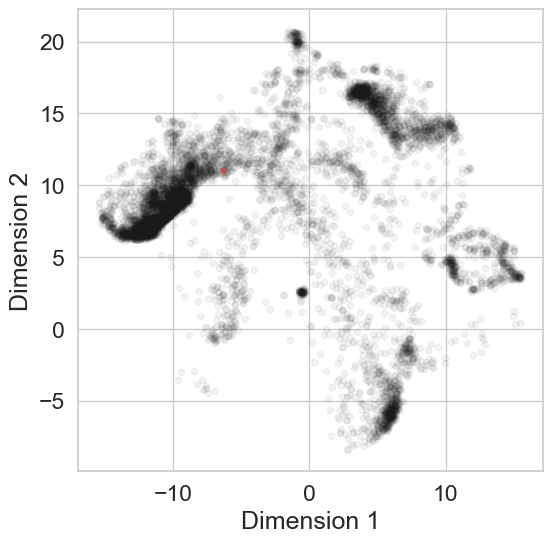

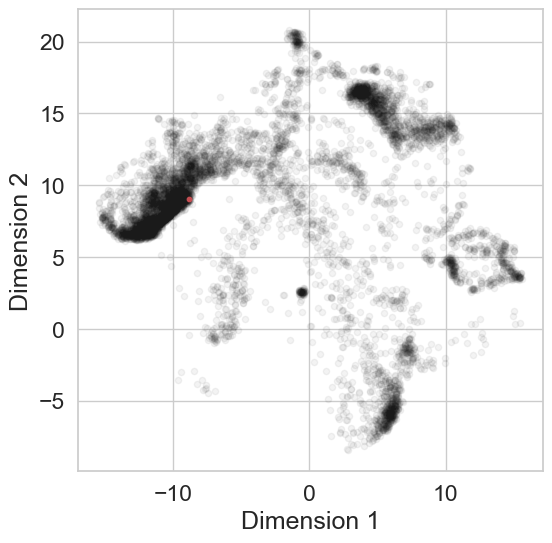

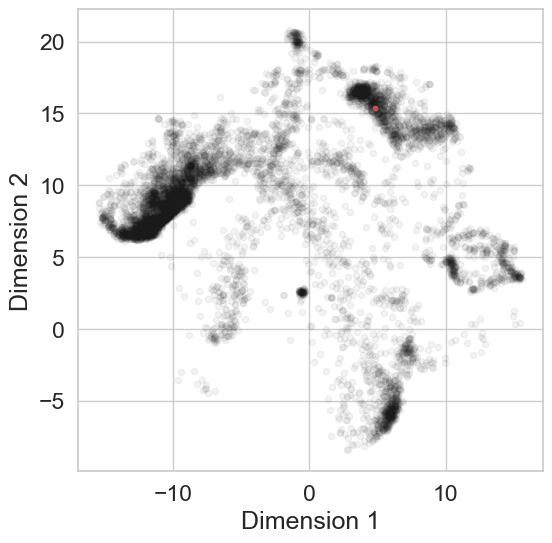

In [33]:
from pyrfume.odorants import embed_molecules

acetophenone = molecules.loc[[7410]]
hexanol = molecules.loc[[8103]]
octen = molecules.loc[[18827]]
heptanone = molecules.loc[[8051]]
etbu = molecules.loc[[7762]]
salicylate = molecules.loc[[4133]]
octyl = molecules.loc[[8164]]
#transhexenal = molecules.loc[[5281168]]
amyl_acetate = molecules.loc[[12348]]
embed_molecules(acetophenone)
embed_molecules(hexanol)
embed_molecules(octen)
embed_molecules(heptanone)
embed_molecules(etbu)
embed_molecules(salicylate)
embed_molecules(octyl)
#embed_molecules(transhexenal)
embed_molecules(amyl_acetate)

In [ ]:
molecule_df = 

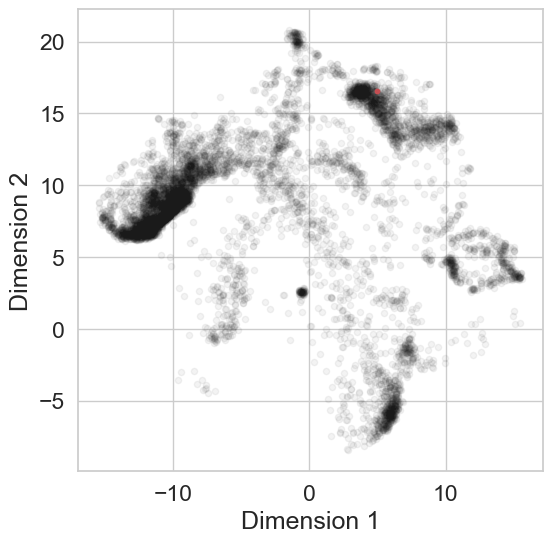

In [39]:
embed_molecules(octen)

In [34]:
from pyrfume.odorants import embed_molecules2

In [69]:
molecules[0:9]

,MolecularWeight,SMILES,IUPACName,name
CID,,,,
8103,102.17,CCCCCCO,hexan-1-ol,1-hexanol
18827,128.21,CCCCCC(C=C)O,oct-1-en-3-ol,1-octen-3-ol
8051,114.19,CCCCCC(=O)C,heptan-2-one,2-heptanone
7410,120.15,CC(=O)C1=CC=CC=C1,1-phenylethanone,acetophenone
7762,116.16,CCCC(=O)OCC,ethyl butanoate,ethyl butyrate
4133,152.15,COC(=O)C1=CC=CC=C1O,methyl 2-hydroxybenzoate,methyl salicylate
8164,172.26,CCCCCCCCOC(=O)C,octyl acetate,octyl acetate
5281168,98.14,CCC/C=C/C=O,(E)-hex-2-enal,trans-2-hexenal
12348,130.18,CCCCCOC(=O)C,pentyl acetate,amyl acetate


In [56]:
type(molecules2)

pandas.core.frame.DataFrame

In [72]:
molecules.index[0]

8103

In [73]:
molecules2 = molecules.drop(5281168)

In [74]:
molecules2

,MolecularWeight,SMILES,IUPACName,name
CID,,,,
8103,102.17,CCCCCCO,hexan-1-ol,1-hexanol
18827,128.21,CCCCCC(C=C)O,oct-1-en-3-ol,1-octen-3-ol
8051,114.19,CCCCCC(=O)C,heptan-2-one,2-heptanone
7410,120.15,CC(=O)C1=CC=CC=C1,1-phenylethanone,acetophenone
7762,116.16,CCCC(=O)OCC,ethyl butanoate,ethyl butyrate
4133,152.15,COC(=O)C1=CC=CC=C1O,methyl 2-hydroxybenzoate,methyl salicylate
8164,172.26,CCCCCCCCOC(=O)C,octyl acetate,octyl acetate
12348,130.18,CCCCCOC(=O)C,pentyl acetate,amyl acetate


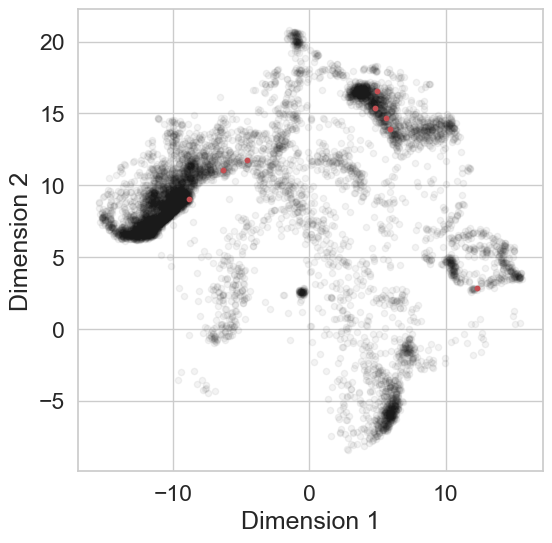

In [75]:
embed_molecules(molecules2)

In [128]:
import pandas as pd
from scipy.spatial import distance_matrix
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr


def get_distance_matrix(features):
    # Compute distance matrix.
    dist = pdist(features, metric="euclidean")
    dist = squareform(dist)
    distances = pd.DataFrame(dist, index=features.index, columns=features.index)
    return distances


def embedding_distance_correlation(original_distances, embedding, quiet=False):
    """
    params:
        original_distances: A pandas DataFrame of distances between objects
        embedding: e.g. a fitted TSNE object
    """
    transformed_distances = distance_matrix(embedding.embedding_, embedding.embedding_)
    transformed_distances = transformed_distances.ravel()
    original_distances = original_distances.values.ravel()
    r, p_r = pearsonr(original_distances, transformed_distances)
    rho, p_rho = spearmanr(original_distances, transformed_distances)
    if not quiet:
        print("R = %.3f; rho = %.3f" % (r, rho))
    return r, rho
